# Step 3 — Gene-wise Self-Attention Model

## Rationale

Genes have **no natural sequence or spatial order** — a standard transformer with positional encoding would impose a false ordering. Instead, we compute a soft attention weight per gene: the model learns *which of the 3000 PCA components matter most* for distinguishing T-cell subtypes, then weights them before the classifier sees them.

This has two practical benefits:
1. **Better source accuracy** — attention focuses the classifier on discriminative genes and suppresses noise
2. **Interpretability** — the learned gene weights tell us biologically which genes drive each class

```
Input x (3000,)
    │
    ├──► Attention MLP: Dense(256)→ReLU→Dense(3000)→Softmax  → weights w (3000,)
    │
    └──► Weighted input: x * w  (elementwise)  → x_att (3000,)
                                │
                         Dense(512)→ReLU→Dropout(0.4)→LayerNorm
                                │
                         Dense(256)→ReLU→Dropout(0.3)
                                │
                         Dense(128)→ReLU→Dropout(0.2)
                                │
                         Dense(n_classes)→Softmax
```

**Context:** MLP baseline got source F1=0.884. DANN got target F1=0.391. This model targets better source F1 and then we evaluate cross-domain to see if gene selection generalises.

In [1]:
import json
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from pathlib import Path
from sklearn.metrics import classification_report, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 120

tf.random.set_seed(42)
np.random.seed(42)

PROJECT_ROOT = Path.cwd().parent.parent if Path.cwd().name == 'step3_self_attention' else Path.cwd()
RESULTS_DIR  = Path('results')
RESULTS_DIR.mkdir(exist_ok=True)
print('Project root:', PROJECT_ROOT)
print('TF:', tf.__version__)

Project root: /Users/kirtan/Projects /NNDL
TF: 2.21.0


## 1. Data Loading

In [2]:
X_train = np.load(PROJECT_ROOT / 'step3_X_train.npy').astype(np.float32)
y_train = np.load(PROJECT_ROOT / 'step3_y_train.npy').astype(np.int64)
X_test  = np.load(PROJECT_ROOT / 'step3_X_test.npy').astype(np.float32)
y_test  = np.load(PROJECT_ROOT / 'step3_y_test.npy').astype(np.int64)

with open(PROJECT_ROOT / 'step3_label_mapping.json') as f:
    label_map = json.load(f)
class_names = [label_map[str(i)] for i in range(len(label_map))]
n_classes   = len(class_names)
n_genes     = X_train.shape[1]

# Target labeled eval set
X_target_raw = np.load(PROJECT_ROOT / 'gse126030_preprocessed.npy').astype(np.float32)
df_labels    = pd.read_csv(PROJECT_ROOT / 'improvements/1_label_validation/label_validation_output/gse126030_reclustered_labels.csv')
mask         = (df_labels['confidence'] >= 0.55) & (df_labels['new_class'] != 'Uncertain')
X_target_eval = X_target_raw[mask.values]
y_target_eval = np.array([class_names.index(n) for n in df_labels.loc[mask, 'new_class']], dtype=np.int64)

# Class weights
classes, counts = np.unique(y_train, return_counts=True)
class_weight = {int(c): len(y_train) / (n_classes * cnt) for c, cnt in zip(classes, counts)}

print(f'Train: {X_train.shape}  Test: {X_test.shape}  Target eval: {X_target_eval.shape}')
print(f'Genes: {n_genes}  Classes: {class_names}')
print(f'Class weights: { {class_names[k]: round(v,3) for k,v in class_weight.items()} }')

Train: (6824, 3000)  Test: (1706, 3000)  Target eval: (12776, 3000)
Genes: 3000  Classes: ['Effector', 'Exhausted', 'Naive', 'Other_CD4', 'Th1-like', 'Treg']
Class weights: {'Effector': np.float64(0.591), 'Exhausted': np.float64(1.71), 'Naive': np.float64(1.267), 'Other_CD4': np.float64(0.886), 'Th1-like': np.float64(2.017), 'Treg': np.float64(0.764)}


## 2. Gene-wise Attention Model

The attention MLP produces a softmax distribution over all 3000 genes. Because softmax sums to 1, the weighted input is a normalised mixture — genes with higher attention contribute more to classification. A separate (deeper) classification MLP then processes the attended features.

In [3]:
def build_gene_attention_model(n_genes, n_classes):
    inputs = keras.Input(shape=(n_genes,), name='gene_expression')

    # --- Attention branch: learns per-gene importance weights ---
    att = layers.Dense(256, activation='relu', name='att_hidden')(inputs)
    att = layers.Dropout(0.3)(att)
    att = layers.Dense(n_genes, activation='softmax', name='gene_weights')(att)
    # att shape: (batch, n_genes) — soft gene selection mask

    # --- Weighted input ---
    weighted = layers.Multiply(name='attended_genes')([inputs, att])
    # Scale back: multiply by n_genes so magnitude is preserved after softmax normalisation
    weighted = layers.Lambda(lambda x: x * n_genes, name='scale')(weighted)

    # --- Classification branch ---
    x = layers.Dense(512, activation='relu')(weighted)
    x = layers.LayerNormalization()(x)
    x = layers.Dropout(0.4)(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.LayerNormalization()(x)
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.2)(x)
    outputs = layers.Dense(n_classes, activation='softmax', name='class_probs')(x)

    model = keras.Model(inputs, outputs, name='GeneAttentionNet')
    return model


model = build_gene_attention_model(n_genes, n_classes)
model.summary()
print(f'\nAttention layer output shape: (batch, {n_genes})')

Model: "GeneAttentionNet"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ gene_expression     │ (None, 3000)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ att_hidden (Dense)  │ (None, 256)       │    768,256 │ gene_expression[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 256)       │          0 │ att_hidden[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gene_weights        │ (None, 3000)      │    771,000 │ dropout[0][0]     │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attended_genes      │ (None, 3000)      │          0 │ gene_expression[… │
│ (Multiply)          │                   │            │ gene_weights[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ scale (Lambda)      │ (None, 3000)      │          0 │ attended_genes[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 512)       │  1,536,512 │ scale[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 512)       │      1,024 │ dense[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 512)       │          0 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 256)       │    131,328 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 256)       │        512 │ dense_1[0][0]     │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 256)       │          0 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 128)       │     32,896 │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 128)       │          0 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ class_probs (Dense) │ (None, 6)         │        774 │ dropout_3[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 3,242,302 (12.37 MB)

 Trainable params: 3,242,302 (12.37 MB)

 Non-trainable params: 0 (0.00 B)


Attention layer output shape: (batch, 3000)


## 3. Training

In [4]:
LEARNING_RATE = 2e-4
BATCH_SIZE    = 128
MAX_EPOCHS    = 100
PATIENCE      = 15

model.compile(
    optimizer=keras.optimizers.Adam(LEARNING_RATE),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='val_loss', mode='min',
        patience=PATIENCE, restore_best_weights=True, verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', mode='min',
        factor=0.5, patience=7, min_lr=1e-6, verbose=1
    ),
]

history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=MAX_EPOCHS,
    batch_size=BATCH_SIZE,
    class_weight=class_weight,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/100
54/54 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.3965 - loss: 1.7271 - val_accuracy: 0.6735 - val_loss: 0.8818 - learning_rate: 2.0000e-04
Epoch 2/100
54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.7232 - loss: 0.7358 - val_accuracy: 0.8400 - val_loss: 0.4646 - learning_rate: 2.0000e-04
Epoch 3/100
54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.8436 - loss: 0.4176 - val_accuracy: 0.8640 - val_loss: 0.3972 - learning_rate: 2.0000e-04
Epoch 4/100
54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9008 - loss: 0.2730 - val_accuracy: 0.8828 - val_loss: 0.3740 - learning_rate: 2.0000e-04
Epoch 5/100
54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9283 - loss: 0.1962 - val_accuracy: 0.8910 - val_loss: 0.3510 - learning_rate: 2.0000e-04
Epoch 6/100
54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9480 - loss: 0.1441 - val_accuracy: 0.8992 - val_loss: 0.3485 - learning_rate: 2.0000e-04
Epoch 7/100
54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 

## 4. Training Curves

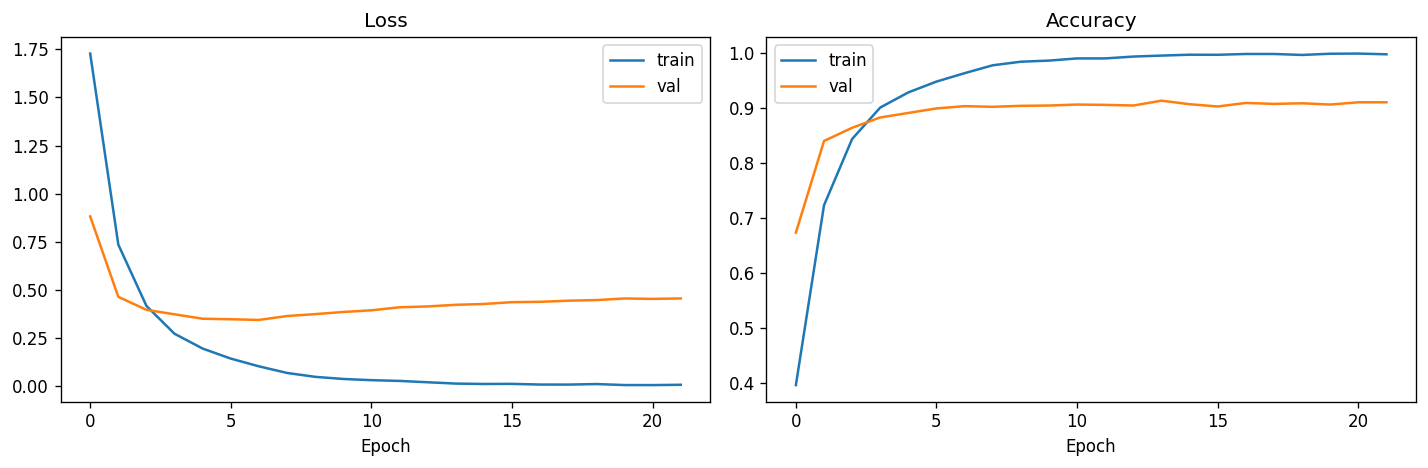

Best val_loss at epoch 7


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history['loss'],     label='train')
axes[0].plot(history.history['val_loss'], label='val')
axes[0].set_title('Loss'); axes[0].set_xlabel('Epoch'); axes[0].legend()

axes[1].plot(history.history['accuracy'],     label='train')
axes[1].plot(history.history['val_accuracy'], label='val')
axes[1].set_title('Accuracy'); axes[1].set_xlabel('Epoch'); axes[1].legend()

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'training_curves.png', bbox_inches='tight')
plt.show()
print(f'Best val_loss at epoch {np.argmin(history.history["val_loss"]) + 1}')

## 5. Source Test Evaluation

In [6]:
y_pred_src = np.argmax(model.predict(X_test, batch_size=BATCH_SIZE), axis=1)
src_f1 = f1_score(y_test, y_pred_src, average='macro')
print(f'Source Test Macro F1: {src_f1:.4f}')
print(classification_report(y_test, y_pred_src, target_names=class_names))

14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
Source Test Macro F1: 0.8942
              precision    recall  f1-score   support

    Effector       0.94      0.94      0.94       482
   Exhausted       0.86      0.96      0.91       166
       Naive       0.84      0.88      0.86       224
   Other_CD4       0.85      0.84      0.85       321
    Th1-like       0.88      0.85      0.87       141
        Treg       0.96      0.92      0.94       372

    accuracy                           0.90      1706
   macro avg       0.89      0.90      0.89      1706
weighted avg       0.90      0.90      0.90      1706



## 6. Cross-Domain Evaluation (Target)

In [7]:
y_pred_tgt = np.argmax(model.predict(X_target_eval, batch_size=BATCH_SIZE), axis=1)
tgt_f1 = f1_score(y_target_eval, y_pred_tgt, average='macro')
print(f'Target Domain Macro F1: {tgt_f1:.4f}')
print(classification_report(y_target_eval, y_pred_tgt, target_names=class_names))

100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
Target Domain Macro F1: 0.0791
              precision    recall  f1-score   support

    Effector       1.00      0.00      0.00      2839
   Exhausted       0.00      0.00      0.00       903
       Naive       0.30      1.00      0.46      3806
   Other_CD4       0.00      0.00      0.00      2127
    Th1-like       0.00      0.00      0.00      1031
        Treg       0.88      0.01      0.01      2070

    accuracy                           0.30     12776
   macro avg       0.36      0.17      0.08     12776
weighted avg       0.45      0.30      0.14     12776



/Users/kirtan/Projects /NNDL/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/kirtan/Projects /NNDL/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/kirtan/Projects /NNDL/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.c

## 7. Confusion Matrices

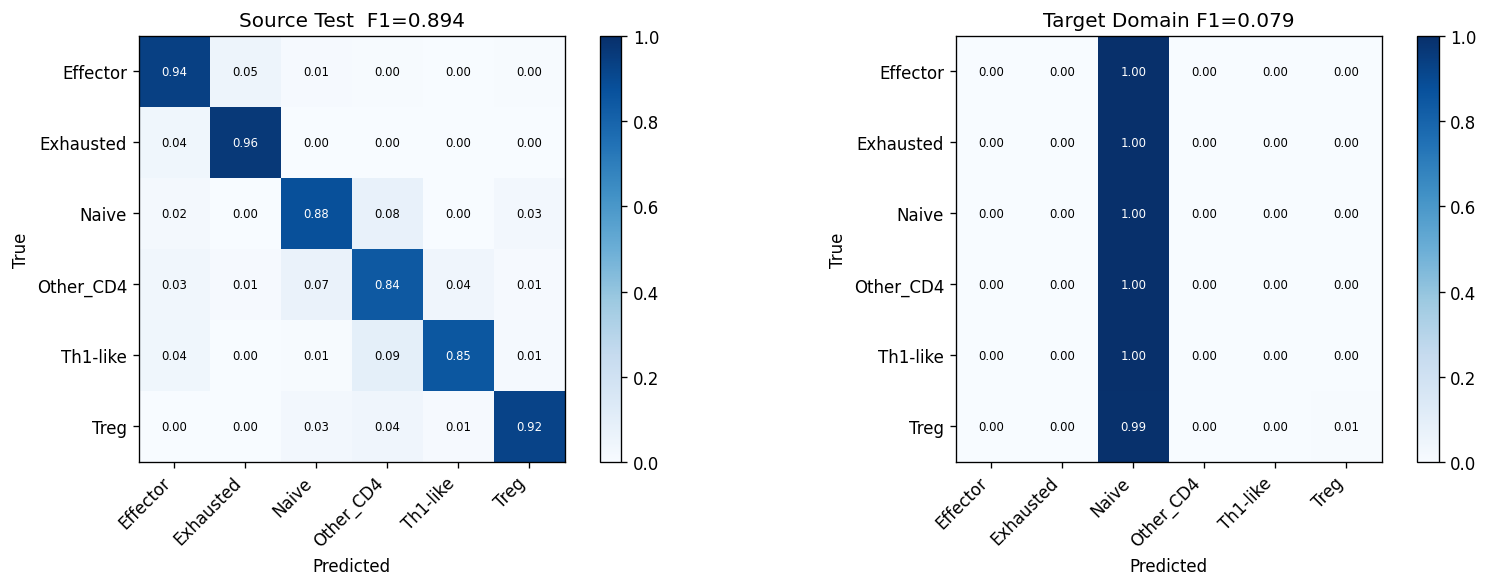

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, y_true, y_pred, title in [
    (axes[0], y_test,        y_pred_src, f'Source Test  F1={src_f1:.3f}'),
    (axes[1], y_target_eval, y_pred_tgt, f'Target Domain F1={tgt_f1:.3f}'),
]:
    cm = confusion_matrix(y_true, y_pred, normalize='true')
    im = ax.imshow(cm, cmap='Blues', vmin=0, vmax=1)
    ax.set_title(title)
    ax.set_xticks(range(n_classes)); ax.set_yticks(range(n_classes))
    ax.set_xticklabels(class_names, rotation=45, ha='right')
    ax.set_yticklabels(class_names)
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
    for i in range(n_classes):
        for j in range(n_classes):
            ax.text(j, i, f'{cm[i,j]:.2f}', ha='center', va='center',
                    color='white' if cm[i,j] > 0.5 else 'black', fontsize=7)
    plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'confusion_matrices.png', bbox_inches='tight')
plt.show()

## 8. Gene Attention Visualisation

Extract the learned attention weights across the test set and visualise which genes (PCA components) receive the highest average attention per class.

14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


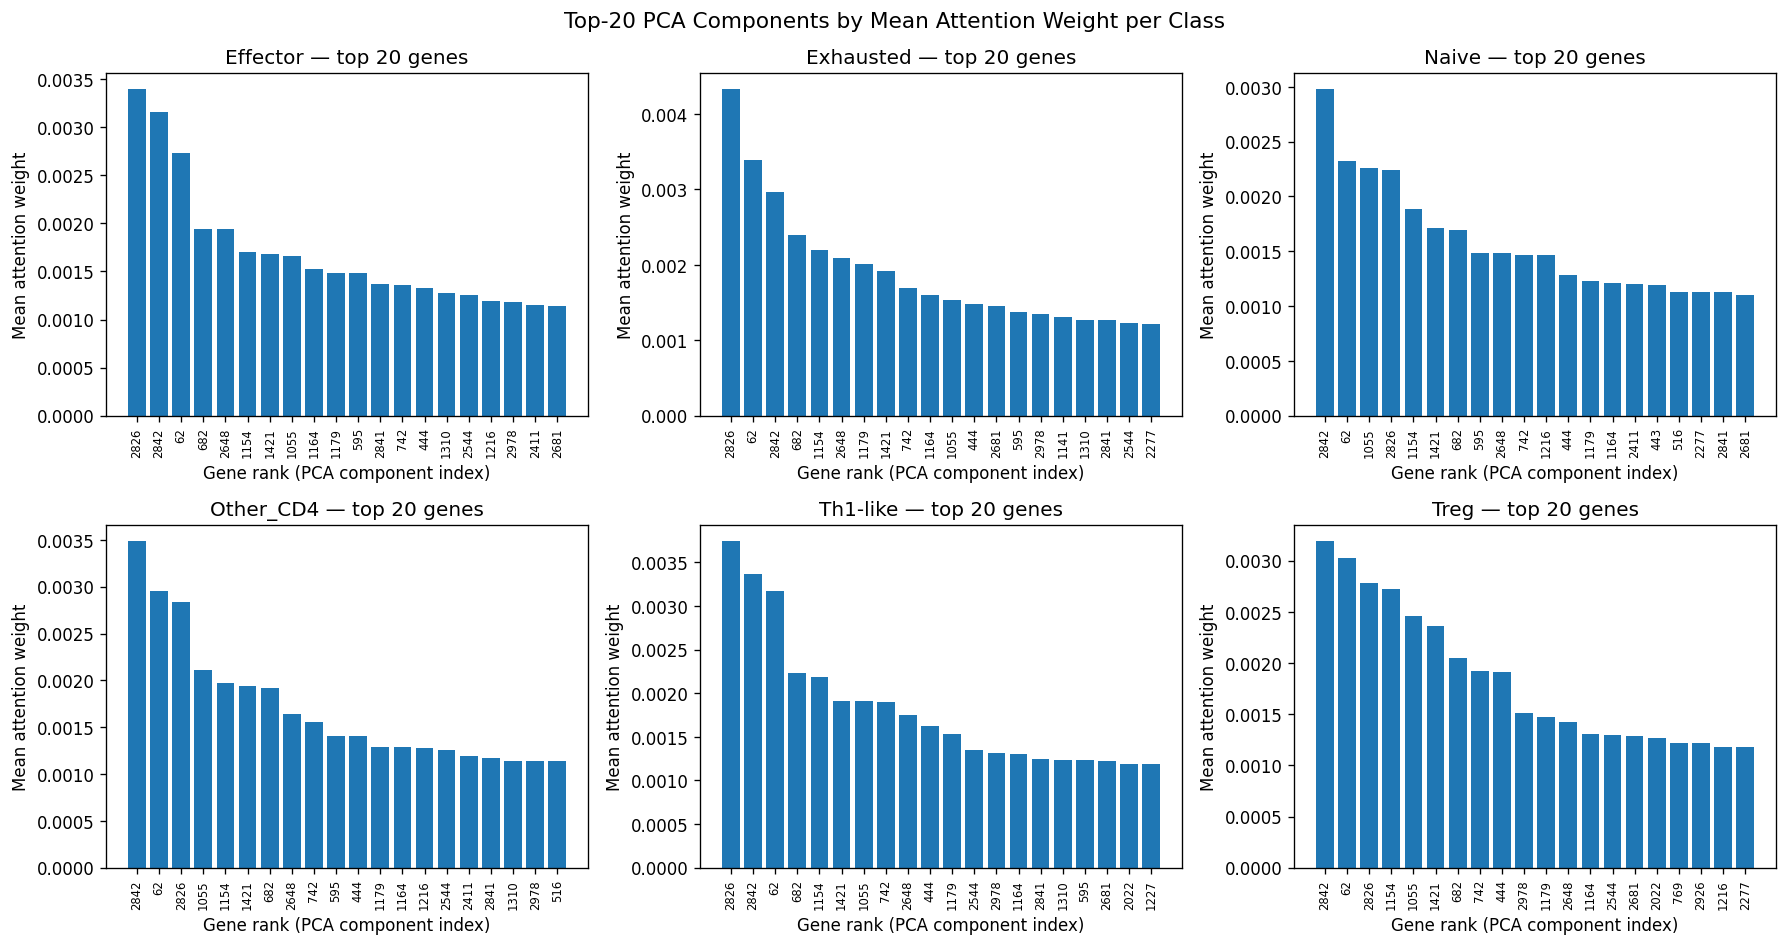

In [9]:
# Build a sub-model that outputs gene attention weights
att_model = keras.Model(
    inputs=model.input,
    outputs=model.get_layer('gene_weights').output
)

# Compute attention weights on the source test set
att_weights = att_model.predict(X_test, batch_size=BATCH_SIZE)  # (n_test, n_genes)

# Average attention per class
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()
top_k = 20

for cls_idx, cls_name in enumerate(class_names):
    cls_mask = y_test == cls_idx
    if cls_mask.sum() == 0:
        continue
    mean_att = att_weights[cls_mask].mean(axis=0)   # (n_genes,)
    top_genes = np.argsort(mean_att)[::-1][:top_k]
    axes[cls_idx].bar(range(top_k), mean_att[top_genes])
    axes[cls_idx].set_title(f'{cls_name} — top {top_k} genes')
    axes[cls_idx].set_xlabel('Gene rank (PCA component index)')
    axes[cls_idx].set_ylabel('Mean attention weight')
    axes[cls_idx].set_xticks(range(top_k))
    axes[cls_idx].set_xticklabels(top_genes, rotation=90, fontsize=7)

plt.suptitle('Top-20 PCA Components by Mean Attention Weight per Class', fontsize=13)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'gene_attention_by_class.png', bbox_inches='tight')
plt.show()

## 9. Compare Against All Previous Models + Save

In [10]:
from sklearn.metrics import accuracy_score

src_report = classification_report(y_test,        y_pred_src, target_names=class_names, output_dict=True)
tgt_report = classification_report(y_target_eval, y_pred_tgt, target_names=class_names, output_dict=True)

results = {
    'model': 'GeneAttentionNet',
    'config': {
        'n_genes': n_genes,
        'attention_hidden': 256,
        'classifier_dims': [512, 256, 128],
        'learning_rate': LEARNING_RATE,
        'batch_size': BATCH_SIZE,
        'epochs_trained': len(history.history['loss']),
        'class_weighted': True,
    },
    'source_test': {
        'macro_f1':  src_f1,
        'accuracy':  accuracy_score(y_test, y_pred_src),
        'per_class_f1': {cls: src_report[cls]['f1-score'] for cls in class_names},
    },
    'target_eval': {
        'macro_f1':  tgt_f1,
        'accuracy':  accuracy_score(y_target_eval, y_pred_tgt),
        'per_class_f1': {cls: tgt_report[cls]['f1-score'] for cls in class_names},
        'n_eval_cells': int(y_target_eval.shape[0]),
    },
}

with open(RESULTS_DIR / 'self_attention_results.json', 'w') as f:
    json.dump(results, f, indent=2)

model.save(str(RESULTS_DIR / 'gene_attention_model.keras'))

# Summary table across all experiments
prior = [
    ('LogReg (source)',   0.885, None),
    ('MLP (source)',      0.884, None),
    ('MMD-Net',           None,  0.194),
    ('DANN v1',           0.852, 0.391),
    ('DANN v2',           0.875, 0.395),
    ('GeneAttentionNet',  src_f1, tgt_f1),
]

print(f'\n{"Model":22s} {"Source F1":>12s} {"Target F1":>12s}')
print('-' * 48)
for name, sf, tf_ in prior:
    s = f'{sf:.3f}' if sf is not None else '   —  '
    t = f'{tf_:.3f}' if tf_ is not None else '   —  '
    print(f'{name:22s} {s:>12s} {t:>12s}')


Model                     Source F1    Target F1
------------------------------------------------
LogReg (source)               0.885          —  
MLP (source)                  0.884          —  
MMD-Net                         —          0.194
DANN v1                       0.852        0.391
DANN v2                       0.875        0.395
GeneAttentionNet              0.894        0.079


/Users/kirtan/Projects /NNDL/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/kirtan/Projects /NNDL/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/kirtan/Projects /NNDL/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.c